F1 Live AI — v5 corrigée
- Modèle 1 (DNF) supprimé car trop mauvais 
- On utilise seulement le Modèle 2 (position) sur tout le monde


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time
import gc
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
# === Chemins ===
DATA_PATH = Path("../data/processed/training_dataset_v2.csv")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [5]:
# === Chargement ===
df = pd.read_csv(DATA_PATH)
print(f"Lignes : {len(df):,}")

# Renommer si nécessaire
if 'lap_time_ms' in df.columns and 'last_lap_time_ms' not in df.columns:
    df = df.rename(columns={'lap_time_ms': 'last_lap_time_ms'})

print(f"Position min : {df['final_position'].min()}")
print(f"Position max : {df['final_position'].max()}")
print(f"Finisseurs   : {(df['final_position'] <= 20).sum():,}")
print(f"DNF          : {(df['final_position'] > 20).sum():,}")



Lignes : 551,742
Position min : 1
Position max : 24
Finisseurs   : 473,075
DNF          : 78,667


In [6]:
# === Features ===
df['lap_time_delta']       = df['last_lap_time_ms'] - df['avg_lap_time_ms']
df['pace_vs_best']         = df['last_lap_time_ms'] - df['best_lap_time_ms']
df['consistency']          = df['lap_time_std'] / (df['avg_lap_time_ms'] + 1)
df['is_early_race']        = (df['race_progress_pct'] < 33).astype(int)
df['is_mid_race']          = ((df['race_progress_pct'] >= 33) & (df['race_progress_pct'] < 66)).astype(int)
df['is_late_race']         = (df['race_progress_pct'] >= 66).astype(int)
df['position_momentum']    = df['grid_position'] - df['current_position']
df['has_pitted']           = (df['nb_pit_stops'] > 0).astype(int)
df['pit_frequency']        = df['nb_pit_stops'] / (df['lap'] + 1)
df['late_top5']            = ((df['current_position'] <= 5) & (df['is_late_race'] == 1)).astype(int)
df['recovery_potential']   = df['laps_remaining'] / (df['current_position'] + 1)
df['pace_gap_to_leader']   = df.groupby(['raceId', 'lap'])['last_lap_time_ms'].transform(lambda x: x - x.min())
df['overtake_opportunity'] = df['grid_position'] - df['current_position']

# Cibles
df['is_top3'] = (df['final_position'] <= 3).astype(int)
df['is_dnf']  = (df['final_position'] > 20).astype(int)

print(f"Features créées. Colonnes : {df.shape[1]}")



Features créées. Colonnes : 50


In [7]:
# === Split ===
EXCLUDE_COLS = [
    'raceId', 'driverId', 'constructorId', 'circuitId',
    'final_position', 'is_dnf', 'is_top3', 'is_winner',
]
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"Nombre de features : {len(feature_cols)}")

train_df = df[df['year'] <= 2019].copy()
val_df   = df[(df['year'] >= 2020) & (df['year'] <= 2021)].copy()
test_df  = df[df['year'] >= 2022].copy()

print(f"Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")


Nombre de features : 43
Train : 472,504 | Val : 42,088 | Test : 37,150


In [8]:
# ================================================================
# MODÈLE : Prédire la position finale (1 à 20)
# On entraîne sur les FINISSEURS seulement — données plus propres
# ================================================================
print("\n" + "="*50)
print("MODÈLE : Prédiction position (1 à 20)")
print("  → Entraîné sur les finisseurs seulement")
print("="*50)

# Garder seulement les finisseurs pour l'entraînement
train_fin = train_df[train_df['final_position'] <= 20].copy()
val_fin   = val_df[val_df['final_position'] <= 20].copy()
test_fin  = test_df[test_df['final_position'] <= 20].copy()

print(f"\nFinisseurs — Train : {len(train_fin):,} | Val : {len(val_fin):,} | Test : {len(test_fin):,}")

X_train = train_fin[feature_cols]
y_train = train_fin['final_position']
X_val   = val_fin[feature_cols]
y_val   = val_fin['final_position']
X_test  = test_fin[feature_cols]
y_test  = test_fin['final_position']

# Sample weights
progress       = train_fin['race_progress_pct'] / 100.0
bonus_top3     = np.where(train_fin['is_top3'] == 1, 2.0, 1.0)
sample_weights = ((1.0 + 2.0 * progress) * bonus_top3).values

# Sous-échantillon pour Optuna
np.random.seed(RANDOM_STATE)
idx_tune = np.random.choice(len(X_train), 80_000, replace=False)
X_tune   = X_train.iloc[idx_tune]
y_tune   = y_train.iloc[idx_tune]
w_tune   = sample_weights[idx_tune]


MODÈLE : Prédiction position (1 à 20)
  → Entraîné sur les finisseurs seulement

Finisseurs — Train : 399,520 | Val : 39,258 | Test : 34,297


In [9]:
# === Optuna ===
print("\nTuning Optuna (100 essais)...")

def objectif(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 500, 2000),
        'max_depth'        : trial.suggest_int('max_depth', 4, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 100),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    modele = lgb.LGBMRegressor(
        **params,
        tree_learner='serial',
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )
    modele.fit(X_tune, y_tune, sample_weight=w_tune)

    preds = np.clip(modele.predict(X_val), 1, 20)
    mae   = mean_absolute_error(y_val, preds)
    r2    = r2_score(y_val, preds)

    return mae - r2


t0    = time.time()
study = optuna.create_study(direction='minimize')
study.optimize(objectif, n_trials=100)

print(f"\nOptuna terminé en {(time.time()-t0)/60:.1f} min")
print(f"Meilleurs paramètres :")
for k, v in study.best_params.items():
    print(f"   {k} : {round(v, 4) if isinstance(v, float) else v}")



Tuning Optuna (100 essais)...

Optuna terminé en 18.3 min
Meilleurs paramètres :
   n_estimators : 606
   max_depth : 7
   learning_rate : 0.0135
   num_leaves : 37
   subsample : 0.6425
   colsample_bytree : 0.8374
   min_child_samples : 32
   reg_alpha : 0.0001
   reg_lambda : 0.0


In [10]:
# === Entraînement final ===
print("\nEntraînement final sur tous les finisseurs...")

t0 = time.time()
model_pos = lgb.LGBMRegressor(
    **study.best_params,
    tree_learner='serial',
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1
)
model_pos.fit(X_train, y_train, sample_weight=sample_weights)
print(f"Terminé en {(time.time()-t0)/60:.1f} min")

gc.collect()


Entraînement final sur tous les finisseurs...
Terminé en 0.3 min


303

In [11]:
# === Évaluation sur finisseurs ===
preds_test = np.clip(model_pos.predict(X_test), 1, 20)
mae_fin    = mean_absolute_error(y_test, preds_test)
r2_fin     = r2_score(y_test, preds_test)

print(f"\nRésultats sur finisseurs :")
print(f"  MAE : {mae_fin:.3f}  (ancien : 1.774)")
print(f"  R²  : {r2_fin:.3f}  (ancien : 0.738)")




Résultats sur finisseurs :
  MAE : 1.309  (ancien : 1.774)
  R²  : 0.862  (ancien : 0.738)


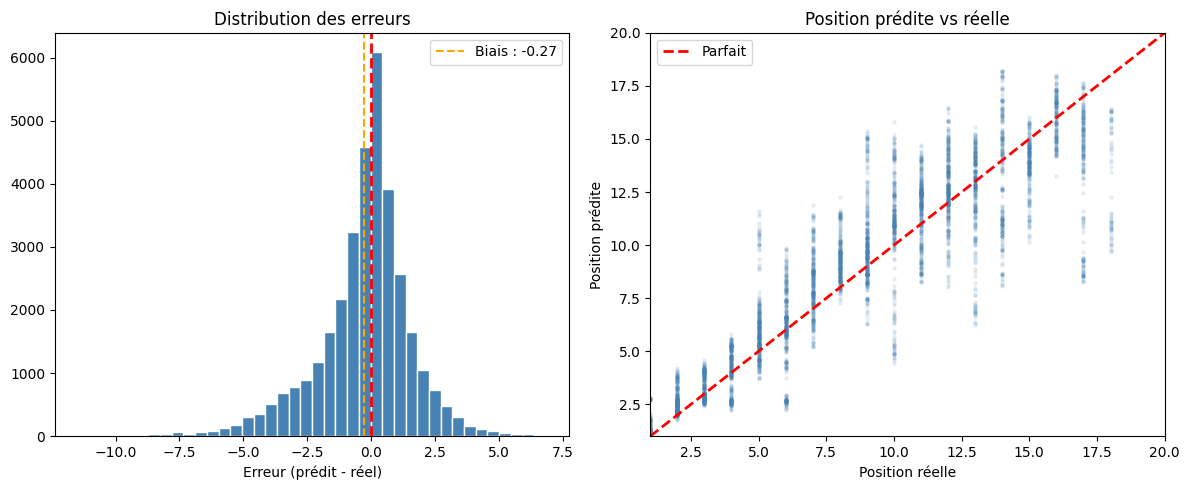

In [12]:
# === Graphique ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Distribution des erreurs
erreurs = preds_test - y_test.values
axes[0].hist(erreurs, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].axvline(erreurs.mean(), color='orange', linestyle='--',
                label=f'Biais : {erreurs.mean():.2f}')
axes[0].set_xlabel('Erreur (prédit - réel)')
axes[0].set_title('Distribution des erreurs')
axes[0].legend()

# Prédit vs réel
axes[1].scatter(y_test.values[:5000], preds_test[:5000],
                alpha=0.1, color='steelblue', s=5)
axes[1].plot([1, 20], [1, 20], 'r--', linewidth=2, label='Parfait')
axes[1].set_xlabel('Position réelle')
axes[1].set_ylabel('Position prédite')
axes[1].set_title('Position prédite vs réelle')
axes[1].set_xlim(1, 20)
axes[1].set_ylim(1, 20)
axes[1].legend()

plt.tight_layout()
plt.savefig(MODEL_DIR / 'resultats_v5_fixed.png', dpi=100)
plt.show()

In [13]:
# === Sauvegarde ===
joblib.dump(model_pos,    MODEL_DIR / 'f1_model_position_v5.pkl')
joblib.dump(feature_cols, MODEL_DIR / 'feature_names_v5.pkl')

print(f"\n============================================")
print(f"      RÉSULTATS FINAUX")
print(f"============================================")
print(f"  MAE test : 1.774 (ancien)  →  {mae_fin:.3f}")
print(f"  R²  test : 0.738 (ancien)  →  {r2_fin:.3f}")
print(f"  Features : 38   (ancien)  →  {len(feature_cols)}")
print(f"  Dataset  : ancien          →  v2 avec qualifying")
print(f"============================================")


      RÉSULTATS FINAUX
  MAE test : 1.774 (ancien)  →  1.309
  R²  test : 0.738 (ancien)  →  0.862
  Features : 38   (ancien)  →  43
  Dataset  : ancien          →  v2 avec qualifying
